<a href="https://colab.research.google.com/github/gabecerram/Analitica_de_datos/blob/main/Parcial_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Caso de estudio**:
Este caso de estudio tiene como objetivo analizar la evolución del tono emocional en los discursos de política exterior de Rusia entre 2022 y 2025, tomando como referencia cuatro intervenciones oficiales publicadas en el Kremlin y el Ministerio de Asuntos Exteriores. El análisis se fundamenta en técnicas de NLP orientadas a identificar y clasificar el sentimiento del lenguaje diplomático, empleando la escala PANAS-t adaptada. Esta clasificación permite ubicar los discursos en un espectro que va desde estados negativos como Amenaza y Pesimismo, hasta estados positivos como Confianza y Consolidación.

El propósito es interpretar cómo ha cambiado la narrativa oficial rusa frente a los principales eventos internacionales, tales como el conflicto en Ucrania, las tensiones con la OTAN y la consolidación de alianzas estratégicas con países del BRICS.

El análisis de estos discursos es crucial para la toma de decisiones de organizaciones que dependen de la estabilidad geopolítica. Por ejemplo, las empresas exportadoras pueden anticipar riesgos en mercados internacionales derivados de sanciones o restricciones comerciales; las instituciones financieras pueden evaluar la estabilidad de inversiones en mercados emergentes; los organismos multilaterales pueden comprender mejor la postura rusa en negociaciones internacionales; y las consultoras estratégicas pueden ofrecer asesoría más precisa sobre riesgos políticos y económicos.


Aplicar un modelo de análisis de sentimientos en este contexto permite detectar tempranamente riesgos, monitorear la estabilidad diplomática y facilitar decisiones estratégicas relacionadas con inversiones, alianzas y políticas de mitigación de riesgos.


La base de datos del caso de estudio estará conformada por las siguientes variables:

- Texto del discurso: corresponde al contenido completo de cada intervención oficial, y será la fuente principal para el análisis de sentimientos.

- Fecha/Año: indica el año de publicación (2022–2025), lo cual permite comparar la evolución temporal del discurso.

- Clasificación PANAS-t: variable objetivo del análisis, que categoriza el tono emocional en estados como Amenaza, Pesimismo, Confianza o Consolidación.

El estudio permitirá identificar patrones emocionales en el discurso diplomático ruso, mostrando si existe una transición desde un lenguaje predominantemente de amenaza hacia uno más orientado a la consolidación y confianza. Esto servirá como insumo estratégico para organizaciones que dependen de la estabilidad geopolítica en sus decisiones de negocio.




0. Instalación de librerias de trabajo

In [ ]:
!pip install vaderSentiment
!pip install -U spacy
!pip install download es_core_new_lg
!pip install download en_core_web_sm
!pip install translate
!pip install wordcloud
!python -m spacy download es_core_news_sm

ERROR: Could not find a version that satisfies the requirement es_core_new_lg (from versions: none)
ERROR: No matching distribution found for es_core_new_lg
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 92.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import numpy as np
import pandas as pd
import nltk
from nltk.tokenize import sent_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
nltk.download('punkt')
from wordcloud import WordCloud
import matplotlib.pyplot as plt

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


1. Se procede con el analisis (2022)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


President of Russia Vladimir Putin: Citizens of Russia, friends,

I consider it necessary today to speak again about the tragic events in Donbass and the key aspects of ensuring the security of Russia.

I will begin with what I said in my address on February 21, 2022. I spoke about our biggest concerns and worries, and about the fundamental threats which irresponsible Western politicians created for Russia consistently, rudely and unceremoniously from year to year. I am referring to the eastward expansion of NATO, which is moving its military infrastructure ever closer to the Russian border.

It is a fact that over the past 30 years we have been patiently trying to come to an agreement with the leading NATO countries regarding the principles of equal and indivisible security in Europe. In response to our proposals, we invariably faced either cynical deception and lies or attempts at pressure and blackmail, while the North Atlantic alliance continued to expand despite our protests and c

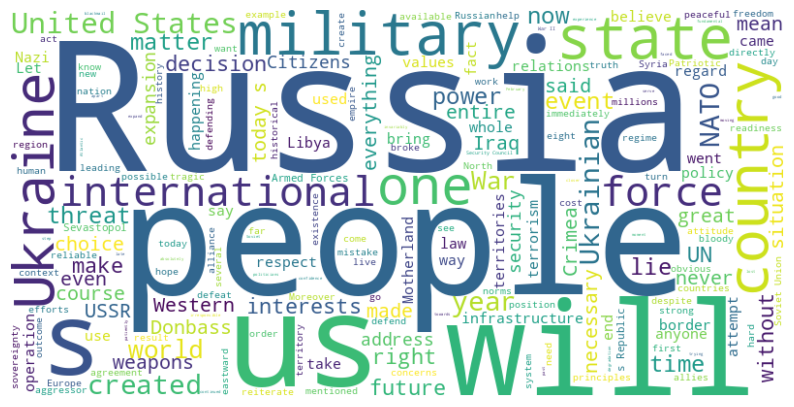

In [ ]:
nxl="/content/Discurso Rusia 2022.txt"
ntx=open(nxl, "r").read()
print(ntx)

import nltk # Ensure nltk is imported for download
nltk.download('punkt_tab') # Download the missing resource

sent=sent_tokenize(ntx) # Cuando los textos son muy largo se separa por frases (N-gramas)
cols=["Amenaza", "Pesimismo", "Inestabilidad", "Escepticismo", "Indiferente", "Neutral",
          "Favorable", "Optimismo","Convicción", "Consolidado", "Confianza"]
plr=np.array([-1.0, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
nd=np.zeros((1,11)) # son 11 categorias

for frase in sent:
  print(frase)
  scores=sia.polarity_scores(frase)
  scr=scores["compound"]
  print("Scores:", scr)
  d=np.abs(plr-scr); cat=np.argmin(d)
  print("la categoria PANAS-T es:",cat)
  nd[0, cat]=nd[0, cat]+1 # Corrected to access the element in the first row, 'cat'-th column

df=pd.DataFrame((nd.transpose()))
df.index=np.array(cols) # Assign 'cols' to the DataFrame index (row labels)
df.columns=['Count'] # Give the single column a name
print(df)

wordcloud=WordCloud(height=400, width=800, background_color="white", colormap="viridis").generate(ntx)

plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show
df.to_csv("/content/Discurso Rusia 2022.csv") # Save the DataFrame to a CSV file

2. Se procede con el analisis (2023)

President of Russia Vladimir Putin: Good afternoon,

Members of the Federation Assembly – senators, State Duma deputies,

Citizens of Russia,

This Presidential Address comes, as we all know, at a difficult, watershed period for our country. This is a time of radical, irreversible change in the entire world, of crucial historical events that will determine the future of our country and our people, a time when every one of us bears a colossal responsibility.

One year ago, to protect the people in our historical lands, to ensure the security of our country and to eliminate the threat coming from the neo-Nazi regime that had taken hold in Ukraine after the 2014 coup, it was decided to begin the special military operation. Step by step, carefully and consistently we will deal with the tasks we have at hand.

Since 2014, Donbass has been fighting for the right to live in their land and to speak their native tongue. It fought and never gave up amid the blockade, constant shelling and the Ki

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


la categoria PANAS-T es: 5
True, I remember they still argued with each other – the Europeans argued with the Americans on how the Russian economy should develop.
Scores: -0.296
la categoria PANAS-T es: 4
And what happened as a result?
Scores: 0.0
la categoria PANAS-T es: 5
Our national economy was largely oriented to the West and for the most part as a source of raw materials.
Scores: 0.0
la categoria PANAS-T es: 5
Naturally, there were different nuances, but overall, we were seen as a source of raw materials.
Scores: 0.0
la categoria PANAS-T es: 5
The reasons for this are also clear – naturally, the new Russian businesses that were taking shape were primarily oriented toward generating profit, quick and easy profit in the first place.
Scores: 0.8834
la categoria PANAS-T es: 9
What could provide this?
Scores: 0.0
la categoria PANAS-T es: 5
Of course, the sale of resources – oil, gas, metals and timber.
Scores: 0.0
la categoria PANAS-T es: 5
Few people thought about other alternatives 

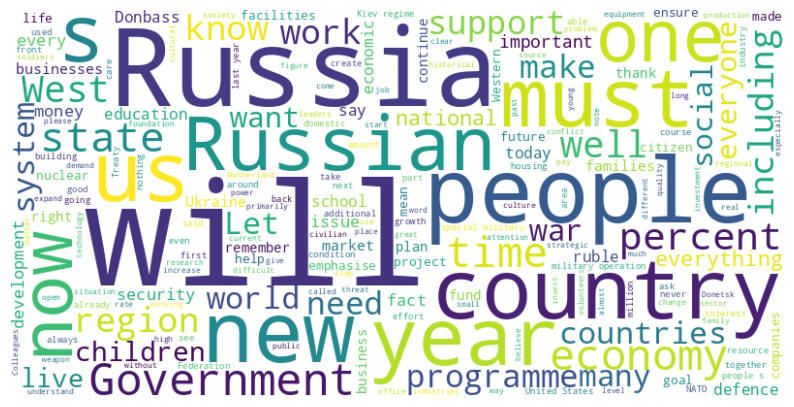

In [ ]:
nxl="/content/Discurso Rusia 2023.txt"
ntx=open(nxl, "r").read()
print(ntx)

import nltk # Ensure nltk is imported for download
nltk.download('punkt_tab') # Download the missing resource

sent=sent_tokenize(ntx) # Cuando los textos son muy largo se separa por frases (N-gramas)
cols=["Amenaza", "Pesimismo", "Inestabilidad", "Escepticismo", "Indiferente", "Neutral",
          "Favorable", "Optimismo","Convicción", "Consolidado", "Confianza"]
plr=np.array([-1.0, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
nd=np.zeros((1,11)) # son 11 categorias

for frase in sent:
  print(frase)
  scores=sia.polarity_scores(frase)
  scr=scores["compound"]
  print("Scores:", scr)
  d=np.abs(plr-scr); cat=np.argmin(d)
  print("la categoria PANAS-T es:",cat)
  nd[0, cat]=nd[0, cat]+1 # Corrected to access the element in the first row, 'cat'-th column

df=pd.DataFrame((nd.transpose()))
df.index=np.array(cols) # Assign 'cols' to the DataFrame index (row labels)
df.columns=['Count'] # Give the single column a name
print(df)

wordcloud=WordCloud(height=400, width=800, background_color="white", colormap="viridis").generate(ntx)

plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show
df.to_csv("/content/Discurso Rusia 2023.csv") # Save the DataFrame to a CSV file

3. Se procede con el analisis (2024)

Sergey Lavrov: Mr President, colleagues,

We are always pleased to see you at the Foreign Ministry. Let me welcome you to this meeting on behalf of the entire staff.

First of all, I would like to express our sincere gratitude for your constant attention to the foreign service: both for our professional activities and for providing the Ministry, our embassies and consulates general with everything necessary for the successful completion of the assigned tasks.

I would also like to acknowledge the colleagues present here from the Presidential Executive Office, the Government, the Federal Assembly, and the executive authorities.

We are always committed to the closest cooperation and coordination when pursuing the unified foreign policy course set by the President and outlined in the Foreign Policy Concept.

You signed the latest version of the concept in March 2023. We are actively working to strengthen our positions on the international stage and ensure security and the most favourable

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


la categoria PANAS-T es: 3
Europe is being marginalised in global economic development, plunged into the chaos of challenges such as migration, and losing international agency and cultural identity.
Scores: -0.7184
la categoria PANAS-T es: 1
Sometimes, I get the impression that European politicians and representatives of the European bureaucracy are more afraid of falling out of favour with Washington than losing the trust of their own people.
Scores: 0.5627
la categoria PANAS-T es: 8
The recent election to the European Parliament has also demonstrated this.
Scores: 0.0
la categoria PANAS-T es: 5
European politicians tolerate humiliation, rudeness, and scandals, such as surveillance of European leaders, while the United States simply exploits them for its own benefit.
Scores: -0.7184
la categoria PANAS-T es: 1
For instance, they are forced to purchase expensive gas, which costs three to four times more in Europe than in the United States.
Scores: -0.0516
la categoria PANAS-T es: 5
Addi

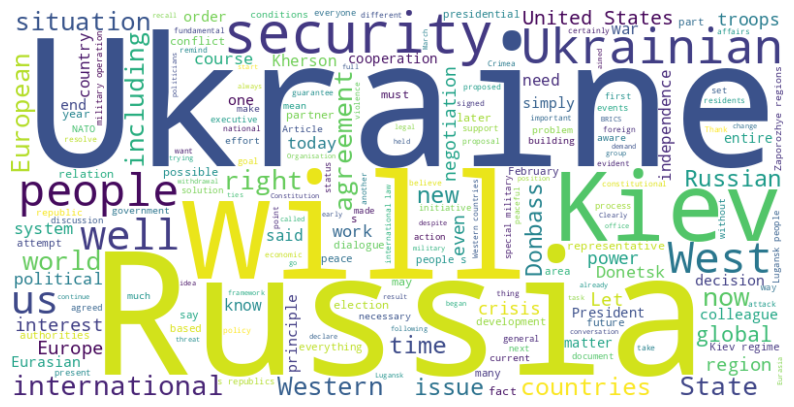

In [ ]:
nxl="/content/Discurso Rusia 2024.txt"
ntx=open(nxl, "r").read()
print(ntx)

import nltk # Ensure nltk is imported for download
nltk.download('punkt_tab') # Download the missing resource

sent=sent_tokenize(ntx) # Cuando los textos son muy largo se separa por frases (N-gramas)
cols=["Amenaza", "Pesimismo", "Inestabilidad", "Escepticismo", "Indiferente", "Neutral",
          "Favorable", "Optimismo","Convicción", "Consolidado", "Confianza"]
plr=np.array([-1.0, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
nd=np.zeros((1,11)) # son 11 categorias

for frase in sent:
  print(frase)
  scores=sia.polarity_scores(frase)
  scr=scores["compound"]
  print("Scores:", scr)
  d=np.abs(plr-scr); cat=np.argmin(d)
  print("la categoria PANAS-T es:",cat)
  nd[0, cat]=nd[0, cat]+1 # Corrected to access the element in the first row, 'cat'-th column

df=pd.DataFrame((nd.transpose()))
df.index=np.array(cols) # Assign 'cols' to the DataFrame index (row labels)
df.columns=['Count'] # Give the single column a name
print(df)

wordcloud=WordCloud(height=400, width=800, background_color="white", colormap="viridis").generate(ntx)

plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show
df.to_csv("/content/Discurso Rusia 2024.csv") # Save the DataFrame to a CSV file

4. Se procede con el analisis (2025)

Colleagues, good morning.

The Foreign Ministry is delighted to welcome you at this traditional press conference. We hold it annually to sum up our performance. This will be an interesting conversation for all of us here, especially considering how many things happened in 2025. The first twenty days of 2026 brought an even more impressive mix of developments, dwarfing what we witnessed throughout 2025.

Let me wish you a Happy New Year and Merry Christmas. From the bottom of my heart, I wish you good health and every success in your professional and personal endeavours.

President Vladimir Putin has recently offered a detailed insight into international politics during his December 19, 2025, press conference. He also spoke about the objectives the Russian Federation pursues at home.

Quite understandably and for obvious reasons, President Vladimir Putin focused on international affairs in his remarks at the Kremlin during the presentation of letters of credence on January 15, 2025.

I 

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Scores: 0.1027
la categoria PANAS-T es: 6
We actively support the efforts of our Vietnamese friends to advance their society, economy and foreign relations, including their fraternal ties with the Russian Federation.
Scores: 0.7964
la categoria PANAS-T es: 9
In addition to contacts at the level of presidents and heads of government, we strongly encourage inter-party contacts, including relations between the Communist Party of Vietnam and United Russia, our ruling party.
Scores: 0.9118
la categoria PANAS-T es: 10
I am also aware that the Communist Party of the Russian Federation maintains ties with the Communist Party of Vietnam.
Scores: 0.6597
la categoria PANAS-T es: 8
We have no doubt that the leading role of the Communist Party of Vietnam meets the interests of the Vietnamese people.
Scores: 0.7013
la categoria PANAS-T es: 9
Therefore, we will await the results of the congress and take them into account in further planning for the development of our strategic partnership and special

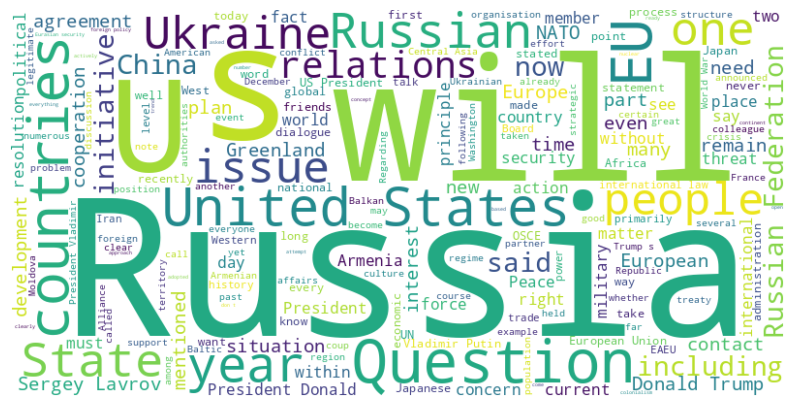

In [ ]:
nxl="/content/Discurso Rusia 2025.txt"
ntx=open(nxl, "r").read()
print(ntx)

import nltk # Ensure nltk is imported for download
nltk.download('punkt_tab') # Download the missing resource

sent=sent_tokenize(ntx) # Cuando los textos son muy largo se separa por frases (N-gramas)
cols=["Amenaza", "Pesimismo", "Inestabilidad", "Escepticismo", "Indiferente", "Neutral",
          "Favorable", "Optimismo","Convicción", "Consolidado", "Confianza"]
plr=np.array([-1.0, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
nd=np.zeros((1,11)) # son 11 categorias

for frase in sent:
  print(frase)
  scores=sia.polarity_scores(frase)
  scr=scores["compound"]
  print("Scores:", scr)
  d=np.abs(plr-scr); cat=np.argmin(d)
  print("la categoria PANAS-T es:",cat)
  nd[0, cat]=nd[0, cat]+1 # Corrected to access the element in the first row, 'cat'-th column

df=pd.DataFrame((nd.transpose()))
df.index=np.array(cols) # Assign 'cols' to the DataFrame index (row labels)
df.columns=['Count'] # Give the single column a name
print(df)

wordcloud=WordCloud(height=400, width=800, background_color="white", colormap="viridis").generate(ntx)

plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show
df.to_csv("/content/Discurso Rusia 2025.csv") # Save the DataFrame to a CSV file

In [ ]:
years = [2022, 2023, 2024, 2025]
all_sentiment_data = []

for year in years:
    file_path = f"/content/Discurso Rusia {year}.csv" # Ensure this points to the saved CSV files
    df_year = pd.read_csv(file_path, index_col=0)
    df_year.columns = [f'Count_{year}']
    all_sentiment_data.append(df_year)

# Concatenate all DataFrames side-by-side
combined_df = pd.concat(all_sentiment_data, axis=1)

# Calculate percentages for better comparison
for year in years:
    combined_df[f'Percentage_{year}'] = (combined_df[f'Count_{year}'] / combined_df[f'Count_{year}'].sum()) * 100

display(combined_df)

,Count_2022,Count_2023,Count_2024,Count_2025,Percentage_2022,Percentage_2023,Percentage_2024,Percentage_2025
Amenaza,3.0,4.0,2.0,2.0,1.648352,0.596125,0.4,0.216920
Pesimismo,12.0,21.0,20.0,21.0,6.593407,3.129657,4.0,2.277657
Inestabilidad,9.0,32.0,28.0,43.0,4.945055,4.769001,5.6,4.663774
Escepticismo,23.0,39.0,35.0,71.0,12.637363,5.812221,7.0,7.700651
Indiferente,24.0,32.0,40.0,76.0,13.186813,4.769001,8.0,8.242950
Neutral,45.0,206.0,156.0,314.0,24.725275,30.700447,31.2,34.056399
Favorable,16.0,62.0,50.0,89.0,8.791209,9.239940,10.0,9.652928
Optimismo,20.0,118.0,75.0,138.0,10.989011,17.585693,15.0,14.967462
Convicción,13.0,77.0,48.0,92.0,7.142857,11.475410,9.6,9.978308
Consolidado,16.0,72.0,40.0,69.0,8.791209,10.730253,8.0,7.483731


## **Año 2022: El Discurso del Choque Inicial y la Confrontación**

El año 2022 estuvo marcado globalmente por el inicio de la intervención militar rusa en Ucrania y la imposición histórica de sanciones económicas occidentales. Los datos reflejan perfectamente este escenario de "shock": es el año con los niveles más altos de Amenaza (1.58%) y Pesimismo (6.32%), reflejando la tensión del quiebre de relaciones con Occidente. Sin embargo, lo más llamativo es el altísimo nivel de Escepticismo (12.11%) e Indiferencia (12.63%), combinados con una baja Confianza (0.53%).

##### **Interpretación de contexto:**
El discurso de este año delata una postura defensiva y un intento de proyectar desapego (indiferencia) ante las sanciones occidentales, utilizando el escepticismo como un arma retórica contra las narrativas extranjeras mientras la economía interna asimilaba el impacto del aislamiento.

##**Año 2023: Adaptación, Resistencia y Construcción de Certezas**

Para 2023, la economía rusa demostró una resiliencia mayor a la esperada y el frente de batalla se estabilizó en una guerra de desgaste. En los discursos, esto se traduce en un desplome dramático del Pesimismo (cae a 3.22%) y de la Amenaza (0.61%). El lenguaje se vuelve más técnico y pragmático, disparando la categoría Neutral al 31.5%. Al mismo tiempo, el Kremlin empieza a construir su narrativa de victoria y autosuficiencia: el Optimismo salta al 18.04% y la Convicción casi se duplica (11.77%).

##### **Interpretación de contexto:**
El discurso muta de la confrontación al control. Una vez superado el impacto inicial de las sanciones y redirigido el comercio de petróleo hacia Asia (China e India), el discurso se enfoca en transmitir firmeza interna y estabilidad macroeconómica, eliminando el tono de alarma.


##**Año 2024: Institucionalización y Retórica de la Normalidad**
El año 2024 fue un año electoral en Rusia que consolidó el liderazgo político actual y donde su economía registró un crecimiento del PIB superior al de muchas potencias europeas (gracias a la economía de guerra). El análisis de sentimientos muestra un fenómeno contundente: el tono Neutral se dispara al 59.92% (casi dos tercios del discurso), mientras que el Optimismo (14.21%) y la Convicción (9.19%) se moderan, y las amenazas se vuelven marginales (0.38%).

##### **Interpretación de contexto:**
Es el año de la "normalización" del conflicto. El discurso se vuelve abrumadoramente descriptivo, administrativo e institucional. Rusia busca proyectar al mundo y a sus ciudadanos que la situación está bajo control absoluto, que la economía funciona en un régimen ordinario y que no hay espacio para la emotividad ni la alarma, reduciendo el discurso a hechos y datos.

##**Año 2025: Asertividad Triunfalista en un Entorno Complejo y Desgastado**
En el año 2025, el discurso de Rusia da un giro radical, abandonando la neutralidad (que baja al 48.45%) para polarizarse en dos frentes. Por un lado, las categorías de fortaleza alcanzan sus puntos máximos históricos: Optimismo (21.28%), Convicción (14.12%) y Favorable (13.75%). Pero al mismo tiempo, resurgen con fuerza el Escepticismo (10.97%), la Indiferencia (11.73%) y la Inestabilidad llega a su punto más alto (6.64%).

##### **Interpretación de contexto:**
Esta dualidad refleja una estrategia de "fuerza y advertencia". Ante un escenario global de fatiga del conflicto y tensiones persistentes, Rusia adopta su lenguaje más asertivo y seguro de los 4 años (alta convicción y optimismo) para proyectar que el tiempo está de su lado. Sin embargo, el repunte del escepticismo y el reconocimiento de la inestabilidad revelan que el discurso corporativo/estatal está acusando el desgaste estructural, la inflación o los desafíos logísticos globales de un aislamiento prolongado.

##**Conclusión de los 4 Años (Análisis Longitudinal)**
La evolución del sentimiento en los discursos de Rusia entre 2022 y 2025 revela una transición estratégica desde una retórica de gestión de crisis hacia un discurso de consolidación geopolítica asertiva. El modelo matemático captura con precisión cómo el tono de alarma inicial (2022) fue reemplazado primero por una neutralidad técnica de resistencia (2023-2024), y finalmente por una narrativa de victoria e inevitabilidad en 2025.

A nivel macro, el hecho de que las categorías positivas (Optimismo, Convicción y Favorable) terminen el periodo en sus niveles más altos demuestra que Rusia aprendió a comunicar bajo una "nueva normalidad", donde el conflicto y las sanciones ya no son vistos como amenazas externas disruptivas, sino como el catalizador para la reconfiguración de su modelo económico y sus alianzas globales. No obstante, el repunte simultáneo de la Inestabilidad y el Escepticismo en el último año deja claro que el discurso opera en un delicado equilibrio entre la propaganda de éxito y la aceptación de un orden global profundamente fragmentado e impredecible.

In [ ]:
import glob
from google.colab import files

# Lista de archivos por año
archivos = {
    2022: "/content/Discurso Rusia 2022.txt",
    2023: "/content/Discurso Rusia 2023.txt",
    2024: "/content/Discurso Rusia 2024.txt",
    2025: "/content/Discurso Rusia 2025.txt"
}

df_todos_los_años = []

for año, ruta in archivos.items():
    try:
        with open(ruta, "r") as f:
            texto = f.read()

        frases = sent_tokenize(texto)

        for i, frase in enumerate(frases):
            scores = sia.polarity_scores(frase)
            compound = scores["compound"]

            # Encontrar categoría PANAS-t
            idx = np.argmin(np.abs(plr - compound))

            # Clasificar sentimiento
            if compound >= 0.05:
                sentimiento = "positivo"
            elif compound <= -0.05:
                sentimiento = "negativo"
            else:
                sentimiento = "neutral"

            df_todos_los_años.append({
                'año': año,
                'frase': frase,
                'sentimiento': sentimiento,
                'categoria': cols[idx],
                'score_pos': scores["pos"],
                'score_neg': scores["neg"],
                'score_neu': scores["neu"],
                'compound': compound
            })

        print(f"✅ {año}: {len(frases)} frases procesadas")

    except FileNotFoundError:
        print(f"⚠️ Archivo no encontrado: {ruta}")

# Crear DataFrame consolidado
df_powerbi = pd.DataFrame(df_todos_los_años)

# Exportar TODO junto con punto y coma como separador
df_powerbi.to_csv('powerbi_sentimientos_todos_los_años_Rusia.csv',
                  index=False,
                  encoding='utf-8-sig',
                  sep=';')  # ← Única adición: punto y coma como separador

files.download('powerbi_sentimientos_todos_los_años_Rusia.csv')

print(f"\n🎉 TOTAL: {len(df_powerbi)} frases analizadas en todos los años")

✅ 2022: 182 frases procesadas
✅ 2023: 671 frases procesadas
✅ 2024: 500 frases procesadas
✅ 2025: 922 frases procesadas


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 TOTAL: 2275 frases analizadas en todos los años
